In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 60)
print("NOTEBOOK 1: RFM K-MEANS CLUSTERING")
print("=" * 60)

# Load from Gold mart
df_spark = spark.table("customer_churn_project.gold.mart_customer_segments")
df = df_spark.toPandas()

print(f"\n📊 Loaded {len(df):,} customers from mart_customer_segments")
print(f"\nColumns: {list(df.columns)}")
df.head()

NOTEBOOK 1: RFM K-MEANS CLUSTERING

📊 Loaded 4,338 customers from mart_customer_segments

Columns: ['CustomerID', 'recency_days', 'frequency', 'monetary', 'total_line_items', 'avg_line_value', 'last_purchase_date', 'first_purchase_date', 'customer_lifespan_days', 'r_score', 'f_score', 'm_score', 'rfm_score', 'rfm_segment_code', 'customer_segment', 'is_whale', 'business_priority']


,CustomerID,recency_days,frequency,monetary,total_line_items,avg_line_value,last_purchase_date,first_purchase_date,customer_lifespan_days,r_score,f_score,m_score,rfm_score,rfm_segment_code,customer_segment,is_whale,business_priority
0,18102,5337,60,259657.30,431,602.45,2011-12-09 11:50:00,2010-12-07 16:42:00,366,1,1,1,3,111,Lost,True,P4 - Win-back Campaign
1,16446,5337,2,168472.50,3,56157.50,2011-12-09 09:15:00,2011-05-18 09:52:00,204,1,4,1,6,141,At Risk,True,P3 - Activate & Re-engage
2,15311,5337,91,60632.75,2366,25.63,2011-12-09 12:00:00,2010-12-01 09:41:00,373,1,1,1,3,111,Lost,True,P4 - Win-back Campaign
3,12748,5337,209,33053.19,4412,7.49,2011-12-09 12:20:00,2010-12-01 12:48:00,372,1,1,1,3,111,Lost,True,P4 - Win-back Campaign
4,17389,5337,34,31833.68,213,149.45,2011-12-09 09:38:00,2011-01-12 15:48:00,330,1,1,1,3,111,Lost,True,P4 - Win-back Campaign


In [0]:
print("=" * 60)
print("2. RFM FEATURE PREPARATION")
print("=" * 60)

# Select core RFM features
rfm_features = ['recency_days', 'frequency', 'monetary']
rfm_df = df[rfm_features].copy()

# Handle any potential nulls
rfm_df = rfm_df.dropna()

print(f"RFM features shape: {rfm_df.shape}")
print("\nRFM Descriptive Statistics:")
print(rfm_df.describe())

# Log-transform monetary and frequency to handle skewness (EDA showed heavy right skew)
# Add small constant to avoid log(0)
rfm_log = rfm_df.copy()
rfm_log['monetary_log'] = np.log1p(rfm_df['monetary'])
rfm_log['frequency_log'] = np.log1p(rfm_df['frequency'])
rfm_log['recency_log'] = np.log1p(rfm_df['recency_days'])

# Use log-transformed features for clustering (more Gaussian = better K-Means)
features_for_clustering = ['recency_log', 'frequency_log', 'monetary_log']
X = rfm_log[features_for_clustering].copy()

print("\nLog-transformed RFM features (for clustering):")
print(X.describe())

2. RFM FEATURE PREPARATION
RFM features shape: (4338, 3)

RFM Descriptive Statistics:
       recency_days    frequency      monetary
count   4338.000000  4338.000000    4338.00000
mean    5429.059474     4.272015    2048.68808
std      100.012264     7.697998    8985.23022
min     5337.000000     1.000000       3.75000
25%     5354.000000     1.000000     306.48250
50%     5387.000000     2.000000     668.57000
75%     5478.750000     5.000000    1660.59750
max     5710.000000   209.000000  280206.02000

Log-transformed RFM features (for clustering):
       recency_log  frequency_log  monetary_log
count  4338.000000    4338.000000   4338.000000
mean      8.599538       1.345582      6.588562
std       0.018215       0.683104      1.258438
min       8.582606       0.693147      1.558145
25%       8.585786       0.693147      5.728418
50%       8.591930       1.098612      6.506636
75%       8.608815       1.791759      7.415535
max       8.650149       5.347108     12.543284


3. OPTIMAL K SELECTION
K=2: Inertia=6865.26, Silhouette=0.406
K=3: Inertia=4298.71, Silhouette=0.415
K=4: Inertia=3244.23, Silhouette=0.380
K=5: Inertia=2763.28, Silhouette=0.343
K=6: Inertia=2397.10, Silhouette=0.334
K=7: Inertia=2169.97, Silhouette=0.300
K=8: Inertia=1964.75, Silhouette=0.299
K=9: Inertia=1822.78, Silhouette=0.281
K=10: Inertia=1691.29, Silhouette=0.284


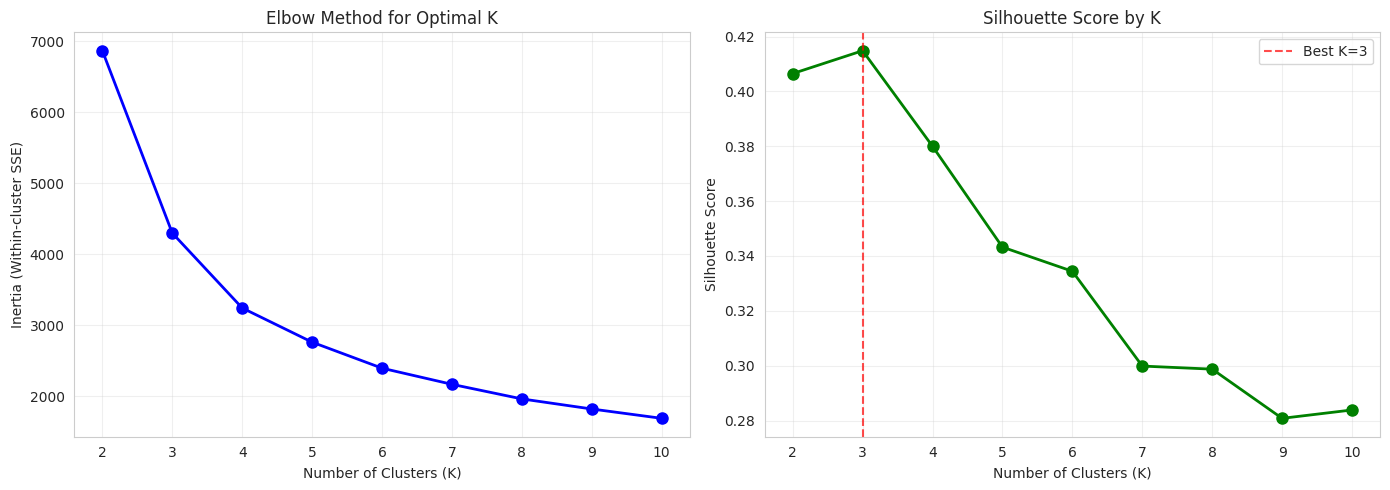


🏆 Recommended K based on Silhouette: 3 (Score: 0.415)


In [0]:
print("=" * 60)
print("3. OPTIMAL K SELECTION")
print("=" * 60)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_score(X_scaled, kmeans.labels_):.3f}")

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(True, alpha=0.3)

# Highlight best K
best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
display(fig)
plt.close()

print(f"\n🏆 Recommended K based on Silhouette: {best_k} (Score: {max(silhouettes):.3f})")

In [0]:
print("=" * 60)
print("4. K-MEANS CLUSTERING")
print("=" * 60)

# Use K=4 (business-interpretable: Champions, Loyal, At-Risk, Lost)
# You can change this to best_k if you prefer data-driven selection
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means fitted with K={OPTIMAL_K}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['cluster']):.3f}")

# Cluster distribution
print("\nCluster Distribution:")
cluster_dist = df['cluster'].value_counts().sort_index()
print(cluster_dist)
print(f"\nCluster %:")
for i in sorted(df['cluster'].unique()):
    pct = (df['cluster'] == i).sum() / len(df) * 100
    print(f"  Cluster {i}: {pct:.1f}%")

# Add cluster labels (we'll name them after analyzing characteristics)
df['cluster_label'] = df['cluster'].map({
    0: 'Cluster 0',
    1: 'Cluster 1', 
    2: 'Cluster 2',
    3: 'Cluster 3'
})

4. K-MEANS CLUSTERING
✅ K-Means fitted with K=4
Silhouette Score: 0.380

Cluster Distribution:
cluster
0    1387
1     944
2    1448
3     559
Name: count, dtype: int64

Cluster %:
  Cluster 0: 32.0%
  Cluster 1: 21.8%
  Cluster 2: 33.4%
  Cluster 3: 12.9%


In [0]:
print("=" * 60)
print("5. CLUSTER PROFILING")
print("=" * 60)

# Profile each cluster
profile = df.groupby('cluster').agg({
    'recency_days': ['mean', 'median'],
    'frequency': ['mean', 'median'],
    'monetary': ['mean', 'median'],
    'rfm_score': ['mean', 'median'],
    'customer_segment': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'N/A'
}).round(2)

print("Cluster Characteristics:")
print(profile)

# Business-friendly naming based on RFM patterns
def name_cluster(row):
    r, f, m = row['recency_days'], row['frequency'], row['monetary']
    # Lower recency = better, higher frequency = better, higher monetary = better
    if r < 30 and f > 10 and m > 2000:
        return 'Champions'
    elif r < 60 and f > 5 and m > 1000:
        return 'Loyal Customers'
    elif r > 90 and f > 5 and m > 1000:
        return 'At Risk'
    elif r > 120 and f <= 3:
        return 'Lost / Dormant'
    else:
        return 'Average'

# Apply naming based on cluster centroids
cluster_names = {}
for c in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == c]
    avg_r = cluster_data['recency_days'].mean()
    avg_f = cluster_data['frequency'].mean()
    avg_m = cluster_data['monetary'].mean()
    name = name_cluster({'recency_days': avg_r, 'frequency': avg_f, 'monetary': avg_m})
    cluster_names[c] = name
    print(f"\nCluster {c}: {name}")
    print(f"  Avg Recency: {avg_r:.0f} days")
    print(f"  Avg Frequency: {avg_f:.1f} transactions")
    print(f"  Avg Monetary: £{avg_m:,.2f}")
    print(f"  Count: {len(cluster_data):,} customers")

df['cluster_business_name'] = df['cluster'].map(cluster_names)

print("\n✅ Business names assigned:")
print(df['cluster_business_name'].value_counts())

5. CLUSTER PROFILING
Cluster Characteristics:
        recency_days         frequency  ... rfm_score        customer_segment
                mean  median      mean  ...      mean median         <lambda>
cluster                                 ...                                  
0            5394.50  5387.0      1.52  ...     10.84   11.0  Loyal Customers
1            5595.40  5591.0      1.38  ...     13.17   14.0        Champions
2            5381.94  5366.0      4.26  ...      6.57    7.0             Lost
3            5355.97  5346.0     16.02  ...      3.67    3.0             Lost

[4 rows x 9 columns]

Cluster 0: Lost / Dormant
  Avg Recency: 5394 days
  Avg Frequency: 1.5 transactions
  Avg Monetary: £389.31
  Count: 1,387 customers

Cluster 1: Lost / Dormant
  Avg Recency: 5595 days
  Avg Frequency: 1.4 transactions
  Avg Monetary: £388.43
  Count: 944 customers

Cluster 2: Average
  Avg Recency: 5382 days
  Avg Frequency: 4.3 transactions
  Avg Monetary: £1,659.38
  Count: 1,44

6. CLUSTER VISUALIZATIONS


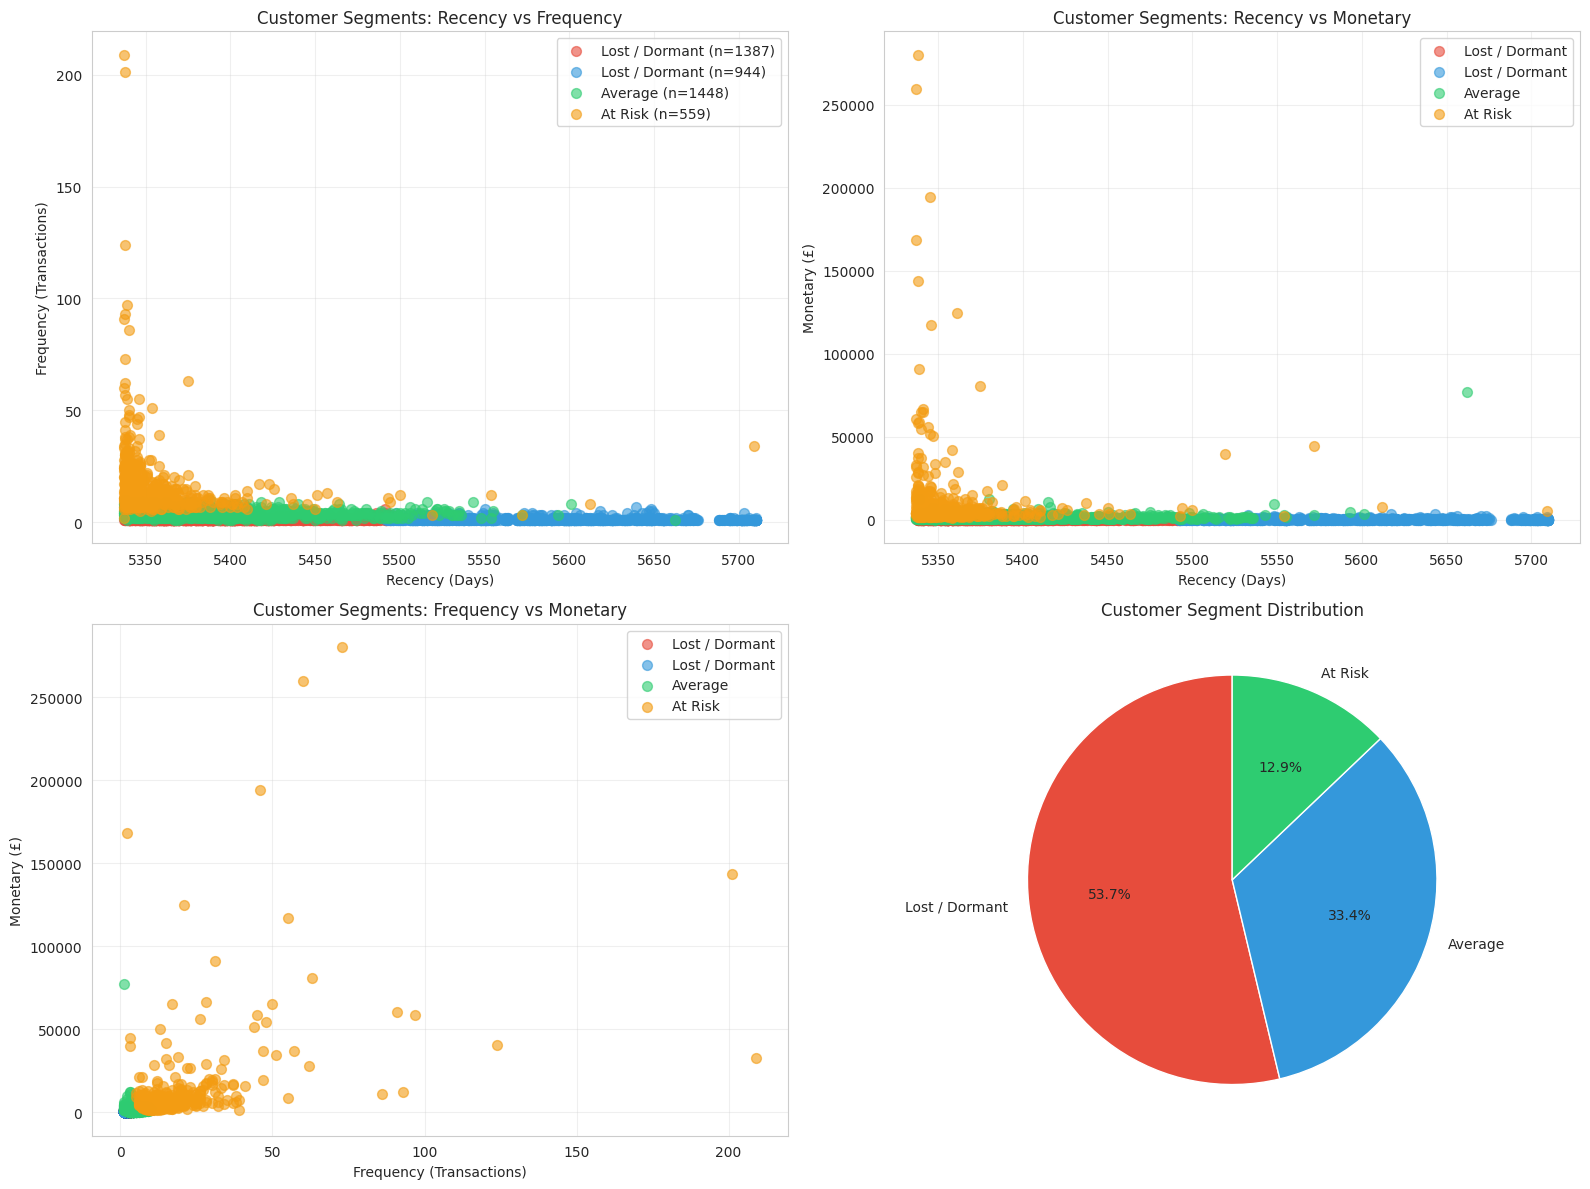


💾 To save this chart: Right-click the image above → 'Save image as'
   Save to: D:\Customer Churn Project\outputs\charts\rfm_kmeans_clusters.png


In [0]:
print("=" * 60)
print("6. CLUSTER VISUALIZATIONS")
print("=" * 60)

# Color palette
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
cluster_colors = {i: colors[i % len(colors)] for i in sorted(df['cluster'].unique())}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Recency vs Frequency
for c in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == c]
    axes[0,0].scatter(cluster_data['recency_days'], cluster_data['frequency'], 
                     c=cluster_colors[c], label=f"{cluster_names[c]} (n={len(cluster_data)})", 
                     alpha=0.6, s=50)
axes[0,0].set_xlabel('Recency (Days)')
axes[0,0].set_ylabel('Frequency (Transactions)')
axes[0,0].set_title('Customer Segments: Recency vs Frequency')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Recency vs Monetary
for c in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == c]
    axes[0,1].scatter(cluster_data['recency_days'], cluster_data['monetary'], 
                     c=cluster_colors[c], label=f"{cluster_names[c]}", 
                     alpha=0.6, s=50)
axes[0,1].set_xlabel('Recency (Days)')
axes[0,1].set_ylabel('Monetary (£)')
axes[0,1].set_title('Customer Segments: Recency vs Monetary')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Frequency vs Monetary
for c in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == c]
    axes[1,0].scatter(cluster_data['frequency'], cluster_data['monetary'], 
                     c=cluster_colors[c], label=f"{cluster_names[c]}", 
                     alpha=0.6, s=50)
axes[1,0].set_xlabel('Frequency (Transactions)')
axes[1,0].set_ylabel('Monetary (£)')
axes[1,0].set_title('Customer Segments: Frequency vs Monetary')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Cluster Size Distribution
cluster_counts = df['cluster_business_name'].value_counts()
axes[1,1].pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%',
             colors=[cluster_colors[c] for c in sorted(df['cluster'].unique())],
             startangle=90)
axes[1,1].set_title('Customer Segment Distribution')

plt.tight_layout()
display(fig)

print("\n💾 To save this chart: Right-click the image above → 'Save image as'")
print("   Save to: D:\\Customer Churn Project\\outputs\\charts\\rfm_kmeans_clusters.png")
plt.close()

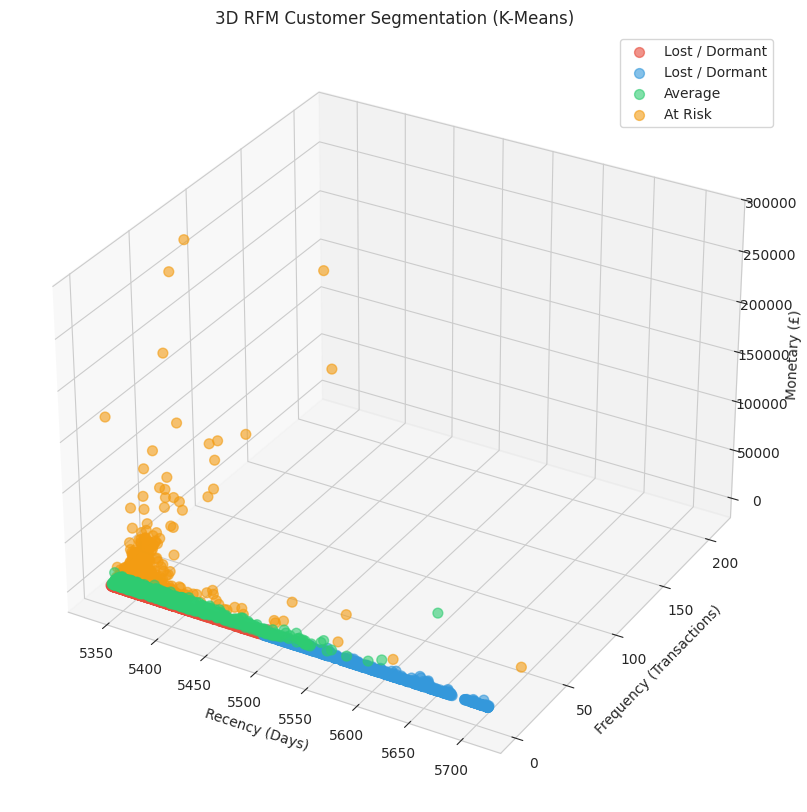

💾 To save: Right-click → 'Save image as' → D:\Customer Churn Project\outputs\charts\rfm_kmeans_3d.png


In [0]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for c in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == c]
    ax.scatter(cluster_data['recency_days'], cluster_data['frequency'], cluster_data['monetary'],
              c=cluster_colors[c], label=cluster_names[c], alpha=0.6, s=50)

ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Transactions)')
ax.set_zlabel('Monetary (£)')
ax.set_title('3D RFM Customer Segmentation (K-Means)')
ax.legend()

display(fig)
print("💾 To save: Right-click → 'Save image as' → D:\\Customer Churn Project\\outputs\\charts\\rfm_kmeans_3d.png")
plt.close()

In [0]:
import json

print("=" * 60)
print("8. SAVE RESULTS TO UNITY CATALOG")
print("=" * 60)

# Save cluster mapping as a Spark DataFrame (no DBFS needed)
cluster_mapping_df = spark.createDataFrame([
    (int(k), v) for k, v in cluster_names.items()
], ["cluster_id", "cluster_name"])

cluster_mapping_df.write \
    .mode("overwrite") \
    .saveAsTable("customer_churn_project.gold.cluster_mapping")

print("✅ Cluster mapping saved to: customer_churn_project.gold.cluster_mapping")

# Export enriched data back to Unity Catalog
df_spark_enriched = spark.createDataFrame(df)
df_spark_enriched.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("customer_churn_project.gold.mart_customer_segments_enriched")

print("✅ Enriched segments saved to: customer_churn_project.gold.mart_customer_segments_enriched")

# Summary for business stakeholders
print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY: RFM K-MEANS SEGMENTATION")
print("=" * 60)
total_customers = len(df)
total_revenue = df['monetary'].sum()

for c in sorted(df['cluster'].unique()):
    segment = cluster_names[c]
    segment_df = df[df['cluster'] == c]
    count = len(segment_df)
    pct = count / total_customers * 100
    revenue = segment_df['monetary'].sum()
    revenue_pct = revenue / total_revenue * 100
    avg_clv = segment_df['monetary'].mean()
    
    print(f"\n🎯 {segment}")
    print(f"   Customers: {count:,} ({pct:.1f}%)")
    print(f"   Revenue Share: £{revenue:,.0f} ({revenue_pct:.1f}%)")
    print(f"   Avg Customer Value: £{avg_clv:,.2f}")
    print(f"   Avg Recency: {segment_df['recency_days'].mean():.0f} days")
    print(f"   Avg Frequency: {segment_df['frequency'].mean():.1f} transactions")

8. SAVE RESULTS TO UNITY CATALOG
✅ Cluster mapping saved to: customer_churn_project.gold.cluster_mapping
✅ Enriched segments saved to: customer_churn_project.gold.mart_customer_segments_enriched

EXECUTIVE SUMMARY: RFM K-MEANS SEGMENTATION

🎯 Lost / Dormant
   Customers: 1,387 (32.0%)
   Revenue Share: £539,974 (6.1%)
   Avg Customer Value: £389.31
   Avg Recency: 5394 days
   Avg Frequency: 1.5 transactions

🎯 Lost / Dormant
   Customers: 944 (21.8%)
   Revenue Share: £366,674 (4.1%)
   Avg Customer Value: £388.43
   Avg Recency: 5595 days
   Avg Frequency: 1.4 transactions

🎯 Average
   Customers: 1,448 (33.4%)
   Revenue Share: £2,402,775 (27.0%)
   Avg Customer Value: £1,659.38
   Avg Recency: 5382 days
   Avg Frequency: 4.3 transactions

🎯 At Risk
   Customers: 559 (12.9%)
   Revenue Share: £5,577,786 (62.8%)
   Avg Customer Value: £9,978.15
   Avg Recency: 5356 days
   Avg Frequency: 16.0 transactions
